In [2]:
!pip install -q scanpy anndata

In [3]:
!pip install -q --upgrade pip

!pip install -q \
    "numpy==1.26.4" \
    "scipy==1.11.4" \
    "pandas==2.1.4" \
    "matplotlib==3.8.4" \
    "seaborn==0.13.2" \
    "anndata==0.10.8" \
    "scanpy==1.10.2" \
    "zarr<3" \
    "numba==0.59.1"

In [1]:
# Load libraries
import os
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
!unzip -q "/content/Project-scRNAseq.zip" -d "/content/Project-scRNAseq"

In [3]:
!find "/content/Project-scRNAseq" -maxdepth 3 -type f

/content/Project-scRNAseq/Project-scRNAseq/Leukemia/barcodes (1).tsv.gz
/content/Project-scRNAseq/Project-scRNAseq/Leukemia/features (1).tsv.gz
/content/Project-scRNAseq/Project-scRNAseq/Leukemia/matrix (1).mtx.gz
/content/Project-scRNAseq/Project-scRNAseq/Normal/barcodes.tsv.gz
/content/Project-scRNAseq/Project-scRNAseq/Normal/matrix.mtx.gz
/content/Project-scRNAseq/Project-scRNAseq/Normal/features.tsv.gz
/content/Project-scRNAseq/Project-scRNAseq/sampleinfo.csv


In [4]:
# Set working directory
os.chdir("/content/Project-scRNAseq/Project-scRNAseq")

In [5]:
print(os.getcwd())
print(os.listdir())

/content/Project-scRNAseq/Project-scRNAseq
['Leukemia', 'Normal', 'sampleinfo.csv']


In [6]:
# Read sample information
sampleinfo = pd.read_csv("sampleinfo.csv")
sampleinfo

,SampleName,type
0,Normal,Illumina HiSeq 4000
1,Leukemia,Illumina HiSeq 4000


In [7]:
!find . -maxdepth 3 -type f | head -30

./Leukemia/barcodes (1).tsv.gz
./Leukemia/features (1).tsv.gz
./Leukemia/matrix (1).mtx.gz
./Normal/barcodes.tsv.gz
./Normal/matrix.mtx.gz
./Normal/features.tsv.gz
./sampleinfo.csv


In [8]:
import os

leukemia_dir = "Leukemia"

os.rename(os.path.join(leukemia_dir, "barcodes (1).tsv.gz"), os.path.join(leukemia_dir, "barcodes.tsv.gz"))
os.rename(os.path.join(leukemia_dir, "features (1).tsv.gz"), os.path.join(leukemia_dir, "features.tsv.gz"))
os.rename(os.path.join(leukemia_dir, "matrix (1).mtx.gz"), os.path.join(leukemia_dir, "matrix.mtx.gz"))

print(os.listdir(leukemia_dir))

['barcodes.tsv.gz', 'matrix.mtx.gz', 'features.tsv.gz']


In [9]:
# Read 10X data (per sample)

adatas = []

for sample in sampleinfo["SampleName"]:

    # Your extracted files are inside:
    # Normal/Normal/ and Leukemia/Leukemia/
    sample_path = f"{sample}"

    adata = sc.read_10x_mtx(
        path=sample_path,
        var_names="gene_symbols",
        cache=True
    )

    # Add sample information
    adata.obs["sample"] = sample

    # Save this dataset in the list
    adatas.append(adata)

print("Successfully loaded:", sampleinfo["SampleName"].tolist())

Successfully loaded: ['Normal', 'Leukemia']


In [10]:
print(adatas)

[AnnData object with n_obs × n_vars = 760 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types', AnnData object with n_obs × n_vars = 971 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types']


In [11]:
type(adatas)

list

In [12]:
type(adata)

anndata._core.anndata.AnnData

In [13]:
# Check the shape of each AnnData object
for adata in adatas:
    sample_name = adata.obs["sample"].unique()[0]
    print(sample_name, adata.shape)


Normal (760, 36601)
Leukemia (971, 36601)


In [14]:
# Extract the AnnData object for sample Leukemia
adata_leukemia = [a for a in adatas if a.obs["sample"].unique()[0] == "Leukemia"][0]
adata_leukemia[:5, :5].X


<5x5 sparse matrix of type '<class 'numpy.float32'>'
	with 0 stored elements in Compressed Sparse Column format>

In [15]:
# Convert the sparse matrix to a DataFrame
adata_leukemia[:5, :5].to_df()


,MIR1302-2HG,FAM138A,OR4F5,AL627309.1,AL627309.3
AAACCTGCAACTGCTA-1,0.0,0.0,0.0,0.0,0.0
AAACCTGGTAGGGTAC-1,0.0,0.0,0.0,0.0,0.0
AAACCTGTCATGCATG-1,0.0,0.0,0.0,0.0,0.0
AAACGGGAGGTTACCT-1,0.0,0.0,0.0,0.0,0.0
AAACGGGCAGGACCCT-1,0.0,0.0,0.0,0.0,0.0


In [16]:
print("Total non-zero entries:", adata_leukemia.X.nnz)
print("Total counts:", adata_leukemia.X.sum())

Total non-zero entries: 2657606
Total counts: 11610152.0


In [17]:
# Check the first few columns (var) of the obs DataFrame for leukemia
adata_leukemia.var.head()

,gene_ids,feature_types
MIR1302-2HG,ENSG00000243485,Gene Expression
FAM138A,ENSG00000237613,Gene Expression
OR4F5,ENSG00000186092,Gene Expression
AL627309.1,ENSG00000238009,Gene Expression
AL627309.3,ENSG00000239945,Gene Expression


In [19]:
# Check the first few rows (obs) of the obs DataFrame for leukemia
adata_leukemia.obs.head()

,sample
AAACCTGCAACTGCTA-1,Leukemia
AAACCTGGTAGGGTAC-1,Leukemia
AAACCTGTCATGCATG-1,Leukemia
AAACGGGAGGTTACCT-1,Leukemia
AAACGGGCAGGACCCT-1,Leukemia


In [20]:
# Merge samples into one object
adata = ad.concat(
    adatas,
    join="outer",
    label="sample_id",
    keys=sampleinfo["SampleName"]
)

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [21]:
print(adata)

AnnData object with n_obs × n_vars = 1731 × 36601
    obs: 'sample', 'sample_id'


In [22]:
adata.X.shape

(1731, 36601)

In [23]:
(adata.X > 0).sum() / (adata.n_obs * adata.n_vars)

0.07108648700001267

In [24]:
adata.X.min(), adata.X.max()

(0.0, 3767.0)

In [ ]:
# Export raw cell metadata
adata.obs.to_csv("cell_metadata_raw.csv")

In [25]:
### Quality control metrics ###
# Number of genes per cell (0, gene absent, non zero, gene present)
adata.obs["n_genes"] = (adata.X > 0).sum(axis=1).A1
adata.obs["n_genes"].head()

,n_genes
AAACCTGAGGACCACA-1,2292
AAACCTGGTTTGGGCC-1,2133
AAACGGGAGCAATATG-1,4722
AAACGGGCATGTCTCC-1,2589
AAACGGGTCGCGCCAA-1,2151


In [26]:
# Compute basic QC metrics
# Total counts/UMIs per cell
adata.obs["n_counts"] = adata.X.sum(axis=1).A1 # Cell_1: gene1 + gene2 + ... + gene56941 = total UMIs counts
adata.obs["n_counts"].head()

,n_counts
AAACCTGAGGACCACA-1,7579.0
AAACCTGGTTTGGGCC-1,8487.0
AAACGGGAGCAATATG-1,19622.0
AAACGGGCATGTCTCC-1,8433.0
AAACGGGTCGCGCCAA-1,7696.0


In [27]:
# Average counts per gene
adata.obs["counts_per_gene"] = adata.obs["n_counts"] / adata.obs["n_genes"]
adata.obs["counts_per_gene"].head()

,counts_per_gene
AAACCTGAGGACCACA-1,3.306719
AAACCTGGTTTGGGCC-1,3.978903
AAACGGGAGCAATATG-1,4.155443
AAACGGGCATGTCTCC-1,3.257242
AAACGGGTCGCGCCAA-1,3.577871


In [28]:
# Identify mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith(("MT-", "mt-"))

In [29]:
# how many mitochondrial genes are there?
adata.var["mt"].sum()

13

In [30]:
# Identify ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))


In [31]:
# how many ribosomal genes are there?
adata.var["ribo"].sum()

103

In [32]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo"],
    percent_top=None,
    log1p=False,
    inplace=True
)

In [33]:
# Check head of obs DataFrame to see the new QC metrics
adata.obs.head()

,sample,sample_id,n_genes,n_counts,counts_per_gene,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
AAACCTGAGGACCACA-1,Normal,Normal,2292,7579.0,3.306719,2292,7579.0,139.0,1.834015,3396.0,44.808022
AAACCTGGTTTGGGCC-1,Normal,Normal,2133,8487.0,3.978903,2133,8487.0,174.0,2.050194,4293.0,50.583244
AAACGGGAGCAATATG-1,Normal,Normal,4722,19622.0,4.155443,4722,19622.0,705.0,3.592906,5947.0,30.307817
AAACGGGCATGTCTCC-1,Normal,Normal,2589,8433.0,3.257242,2589,8433.0,130.0,1.541563,3678.0,43.614372
AAACGGGTCGCGCCAA-1,Normal,Normal,2151,7696.0,3.577871,2151,7696.0,99.0,1.286383,3653.0,47.466217


In [34]:
# export the QC metrics to a CSV file
qc_cols = [
    "sample", "n_counts", "n_genes", "counts_per_gene", "pct_counts_mt", "pct_counts_ribo"
]
adata.obs.to_csv("QC_raw_table.csv")

In [35]:
# Compute counts per gene (average count per gene detected in each cell)
adata.obs["counts_per_gene"] = adata.obs["n_counts"] / adata.obs["n_genes"]

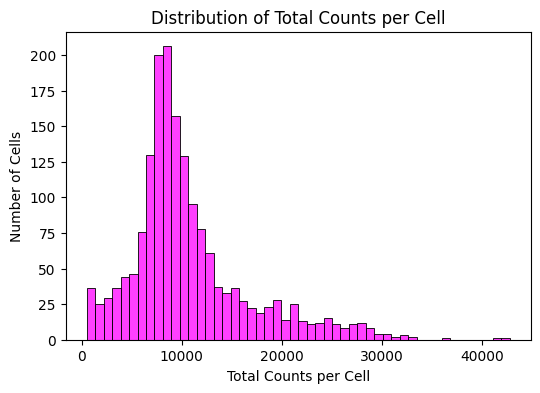

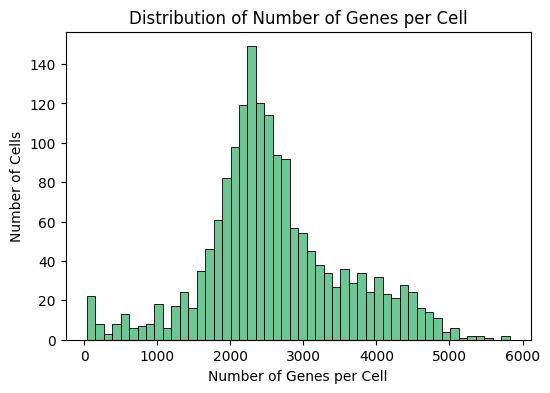

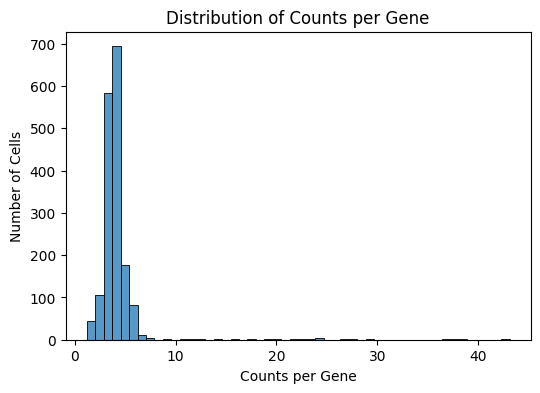

In [36]:
# Histogram of total counts per cell
plt.figure(figsize=(6, 4))
sns.histplot(adata.obs["n_counts"], bins=50, kde=False, color="magenta")
plt.xlabel("Total Counts per Cell")
plt.ylabel("Number of Cells")
plt.title("Distribution of Total Counts per Cell")
plt.show()


# Histogram of number of genes per cell
plt.figure(figsize=(6, 4))
sns.histplot(adata.obs["n_genes"], bins=50, kde=False, color="mediumseagreen")
plt.xlabel("Number of Genes per Cell")
plt.ylabel("Number of Cells")
plt.title("Distribution of Number of Genes per Cell")
plt.show()


# Histogram of counts per gene
plt.figure(figsize=(6, 4))
sns.histplot(adata.obs["counts_per_gene"], bins=50, kde=False)
plt.xlabel("Counts per Gene")
plt.ylabel("Number of Cells")
plt.title("Distribution of Counts per Gene")
plt.show()


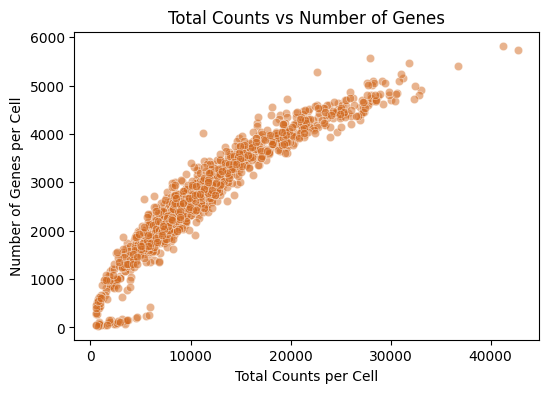

In [37]:
# Scatter plot of total counts vs number of genes
plt.figure(figsize=(6, 4))
sns.scatterplot(x="n_counts", y="n_genes", data=adata.obs, alpha=0.5, color="chocolate")
plt.xlabel("Total Counts per Cell")
plt.ylabel("Number of Genes per Cell")
plt.title("Total Counts vs Number of Genes")
plt.show()

/tmp/ipykernel_3973/434907653.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="sample", y="n_counts", data=adata.obs, palette=["#4C78A8", "#E45756"] )
/tmp/ipykernel_3973/434907653.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="sample", y="n_genes", data=adata.obs, palette=["#E98B50", "#2196F3"] )


Text(0.5, 1.0, 'Number of Genes per Cell by Sample')

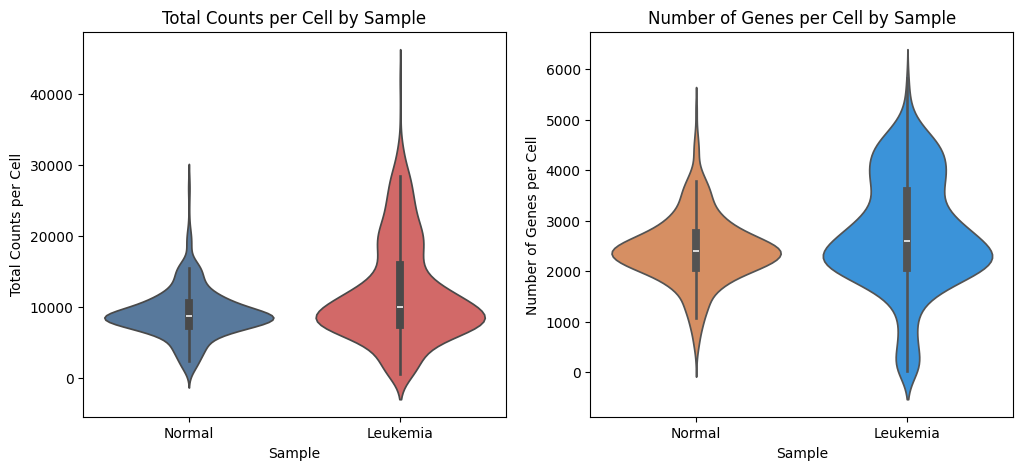

In [38]:
# Make voilen plot of n_counts per sample & n_genes per sample
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.violinplot(x="sample", y="n_counts", data=adata.obs, palette=["#4C78A8", "#E45756"] )
plt.xlabel("Sample")
plt.ylabel("Total Counts per Cell")
plt.title("Total Counts per Cell by Sample")

plt.subplot(1, 2, 2)
sns.violinplot(x="sample", y="n_genes", data=adata.obs, palette=["#E98B50", "#2196F3"] )
plt.xlabel("Sample")
plt.ylabel("Number of Genes per Cell")
plt.title("Number of Genes per Cell by Sample")

In [39]:
print("Cells before filtering:", adata.n_obs)
print("Genes before filtering:", adata.n_vars)

Cells before filtering: 1731
Genes before filtering: 36601


In [40]:
# Check quantiles
adata.obs["n_counts"].quantile([0.01, 0.99])

,n_counts
0.01,805.2
0.99,29346.8


In [41]:
# Check quantiles
adata.obs["n_genes"].quantile([0.01, 0.99])

,n_genes
0.01,117.3
0.99,4900.1


In [42]:
# Check quantiles
adata.obs["counts_per_gene"].quantile([0.01, 0.99])

,counts_per_gene
0.01,1.573973
0.99,20.221891


In [43]:
## Compute quantile thresholds
n_counts_low, n_counts_high = adata.obs["n_counts"].quantile([0.001, 0.999])
n_genes_low, n_genes_high = adata.obs["n_genes"].quantile([0.001, 0.999])
complex_low, complex_high = adata.obs["counts_per_gene"].quantile([0.001, 0.999])

# Define mito and ribo thresholds (biologically guided)
mito_threshold = 15        # Common practice: < 10–20%
ribo_threshold = 50        # Dataset dependent, often < 40–50%

# Apply all filters together
adata_filtered = adata[
    (adata.obs["n_counts"] >= n_counts_low) &
    (adata.obs["n_counts"] <= n_counts_high) &
    (adata.obs["n_genes"] >= n_genes_low) &
    (adata.obs["n_genes"] <= n_genes_high) &
    (adata.obs["counts_per_gene"] >= complex_low) &
    (adata.obs["counts_per_gene"] <= complex_high) &
    (adata.obs["pct_counts_mt"] < mito_threshold) &
    (adata.obs["pct_counts_ribo"] < ribo_threshold),
    :
].copy()

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [44]:
print("Cells after filtering:", adata_filtered.n_obs)
print("Genes after filtering:", adata_filtered.n_vars)
print("Cells removed:", adata.n_obs - adata_filtered.n_obs)

Cells after filtering: 1368
Genes after filtering: 36601
Cells removed: 363


In [45]:
# Export filtered QC metrics
adata_filtered.obs.to_csv("QC_filtered_table.csv")

In [46]:
adata_filtered.shape

(1368, 36601)

In [47]:
adata.shape

(1731, 36601)

/tmp/ipykernel_3973/3798222079.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="sample", y="n_counts", data=adata_filtered.obs, palette= ["#CF4173", "#1B5E20"])
/tmp/ipykernel_3973/3798222079.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="sample", y="n_genes", data=adata_filtered.obs, palette=["#4E1F6E", "#45A9A9"])


Text(0.5, 1.0, 'Number of Genes per Cell by Sample (Filtered)')

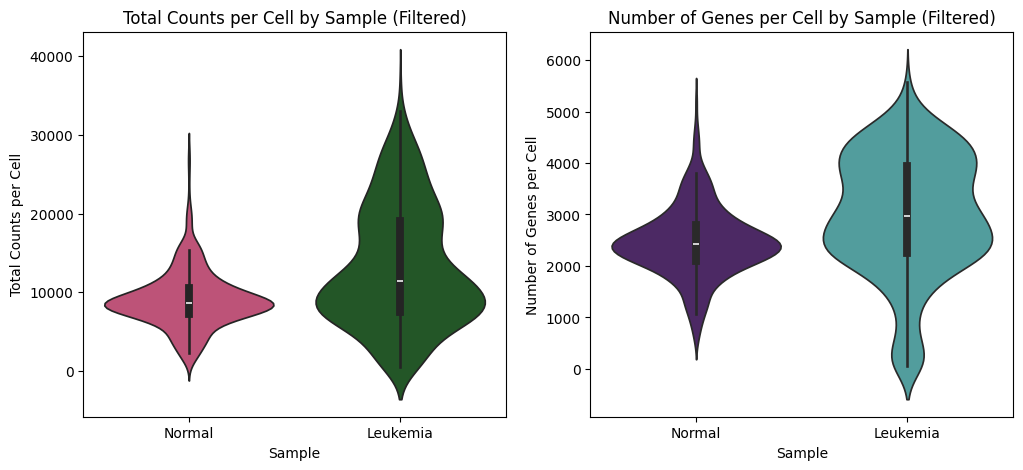

In [48]:
# make voilen plot of n_counts per sample & n_genes per sample after filtering
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.violinplot(x="sample", y="n_counts", data=adata_filtered.obs, palette= ["#CF4173", "#1B5E20"])
plt.xlabel("Sample")
plt.ylabel("Total Counts per Cell")
plt.title("Total Counts per Cell by Sample (Filtered)")

plt.subplot(1, 2, 2)
sns.violinplot(x="sample", y="n_genes", data=adata_filtered.obs, palette=["#4E1F6E", "#45A9A9"])
plt.xlabel("Sample")
plt.ylabel("Number of Genes per Cell")
plt.title("Number of Genes per Cell by Sample (Filtered)")

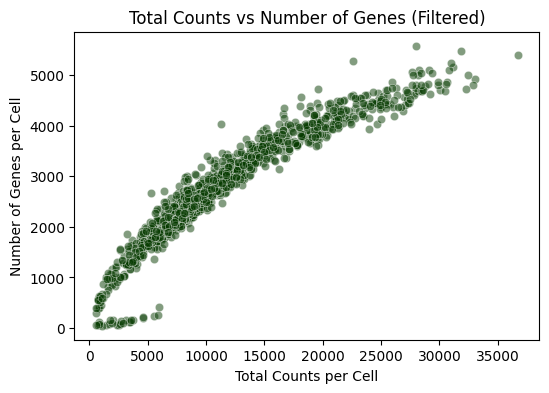

In [49]:
# scatter plot of total counts vs number of genes after filtering
plt.figure(figsize=(6, 4))
sns.scatterplot(x="n_counts", y="n_genes", data=adata_filtered.obs, alpha=0.5, color="#063B00")
plt.xlabel("Total Counts per Cell")
plt.ylabel("Number of Genes per Cell")
plt.title("Total Counts vs Number of Genes (Filtered)")
plt.show()

In [51]:
# Freeze raw counts after QC filtering
adata_filtered.raw = adata_filtered.copy()

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [52]:
# Check the shape of the raw counts after filtering
adata_filtered.raw.X.shape

(1368, 36601)

In [53]:
# Normalize counts (library-size normalization)

sc.pp.normalize_total(
    adata_filtered,
    target_sum=1e4
)

In [54]:
# Total counts per cell (raw)
adata_filtered.obs["total_counts_raw"] = (
    adata_filtered.raw.X.sum(axis=1).A1
)

# Total counts per cell (normalized)
adata_filtered.obs["total_counts_normalized"] = (
    adata_filtered.X.sum(axis=1).A1
)
# Check the first few rows of obs to see the new total counts columns
adata_filtered.obs[["total_counts_raw", "total_counts_normalized"]].head()

,total_counts_raw,total_counts_normalized
AAACCTGAGGACCACA-1,7579.0,10000.000000
AAACGGGAGCAATATG-1,19622.0,10000.000000
AAACGGGCATGTCTCC-1,8433.0,10000.000000
AAACGGGTCGCGCCAA-1,7696.0,10000.000977
AAAGATGGTAGAGTGC-1,8737.0,10000.000000


In [55]:
# Log transform normalized data
sc.pp.log1p(adata_filtered)

In [56]:
# Preserve log-normalized expression
adata_filtered.layers["lognorm"] = adata_filtered.X.copy()

In [57]:
# Identify highly variable genes (HVGs)
sc.pp.highly_variable_genes(
    adata_filtered,
    flavor="seurat",
    n_top_genes=2000
)

In [58]:
# Check the first few rows of var to see the new highly variable gene columns
adata_filtered.var.head()


,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm
MIR1302-2HG,False,False,0,0.000000,100.00000,0.0,False,1.000000e-12,NaN,NaN
FAM138A,False,False,0,0.000000,100.00000,0.0,False,1.000000e-12,NaN,NaN
OR4F5,False,False,0,0.000000,100.00000,0.0,False,1.000000e-12,NaN,NaN
AL627309.1,False,False,2,0.001155,99.88446,2.0,False,6.616179e-04,-0.787595,-2.048674
AL627309.3,False,False,0,0.000000,100.00000,0.0,False,1.000000e-12,NaN,NaN


In [59]:
# Chaeck the number of rows and columns in the adata_filtered.var DataFrame
adata_filtered.var.shape

(36601, 10)

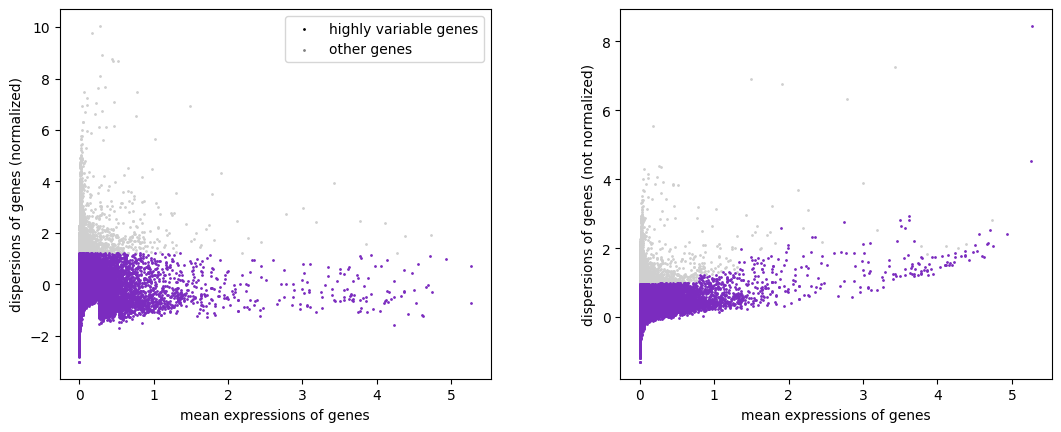

In [60]:
# Visualize highly variable genes in normalized mean vs normalized variance plot
sc.pl.highly_variable_genes(adata_filtered, show =False)

# Get the current figure
fig = plt.gcf()

# Change the point colors
for ax in fig.axes:
    if len(ax.collections) >= 2:
        ax.collections[0].set_color("#CFCFCF")  # other genes
        ax.collections[1].set_color("#7B2CBF")  # highly variable genes

plt.show()

In [ ]:
# Export HVG statistics to CSV
hvg_stats = adata_filtered.var.copy()
hvg_stats.to_csv("HVG_statistics_full.csv")

In [61]:
# Extract only the highly variable genes
hvg_only = adata_filtered.var[
    adata_filtered.var["highly_variable"]
]
hvg_only.head()


,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm
LINC00115,False,False,10,0.005777,99.422299,10.0,True,0.010297,1.102428,1.490796
SAMD11,False,False,4,0.002311,99.768920,4.0,True,0.008200,2.212611,3.569850
HES4,False,False,4,0.002311,99.768920,4.0,True,0.010913,2.287053,3.709258
LINC01342,False,False,1,0.000578,99.942230,1.0,True,0.005131,1.951224,3.080347
SKI,False,False,185,0.119006,89.312536,206.0,True,0.127770,1.080598,1.449914


In [62]:
# number of rows and columns in the hvg_only DataFrame
hvg_only.shape

(2000, 10)

In [63]:
# Export only the highly variable genes statistics to CSV
hvg_only.to_csv("HVG_statistics_HVGonly.csv")

In [64]:
adata_hvg = adata_filtered[
    :, adata_filtered.var["highly_variable"]
].copy()

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [65]:
# Convert the sparse matrix of highly variable genes to a DataFrame
expr_df = pd.DataFrame(
    adata_hvg.X.toarray(),
    index=adata_hvg.obs_names,
    columns=adata_hvg.var_names
)

expr_df.head()


,LINC00115,SAMD11,HES4,LINC01342,SKI,CCDC27,CHD5,PER3,ERRFI1,SLC2A5,...,AL683813.1,Z96074.1,FGF13,FLNA,F8,MTCP1,AC011751.1,MT-ND2,MT-ND4L,AC011043.1
AAACCTGAGGACCACA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.741729,0.000000,0.0
AAACGGGAGCAATATG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.779841,0.411866,0.0
AAACGGGCATGTCTCC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.230092,0.000000,0.0
AAACGGGTCGCGCCAA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.808952,0.000000,0.0
AAAGATGGTAGAGTGC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.173508,0.000000,0.0


In [66]:
print("Total non-zero entries:", adata_hvg.X.nnz if hasattr(adata_hvg.X, 'nnz') else np.count_nonzero(adata_hvg.X))
print("Total counts:", adata_hvg.X.sum())
print("Mean genes detected per cell:", (adata_hvg.X > 0).sum(axis=1).mean())

Total non-zero entries: 257151
Total counts: 279096.0
Mean genes detected per cell: 187.97587719298247


In [67]:
# Export the expression matrix of highly variable genes to CSV
expr_df.to_csv("HVG_expression_matrix.csv")

In [68]:
adata_hvg.shape

(1368, 2000)

In [69]:
# Shape of raw matrix
adata.X.shape

(1731, 36601)

In [70]:
# shape of matrix after QC
adata_filtered.raw.shape

(1368, 36601)

In [71]:
# shape of log-normalized matrix
adata_filtered.layers["lognorm"].shape

(1368, 36601)

In [72]:
# Shape of matrix with only highly variable genes
adata_hvg.shape

(1368, 2000)

In [73]:
# Scale HVGs
sc.pp.scale(
    adata_hvg,
    max_value=10   # clipping extreme values (important for scRNA-seq)
)

In [74]:
# Check scaled matrix head
scaled_df = pd.DataFrame(
    adata_hvg.X[:10, :10],
    index=adata_hvg.obs_names[:10],
    columns=adata_hvg.var_names[:10]
)
scaled_df

,LINC00115,SAMD11,HES4,LINC01342,SKI,CCDC27,CHD5,PER3,ERRFI1,SLC2A5
AAACCTGAGGACCACA-1,-0.071163,-0.035832,-0.042727,-0.027037,-0.301759,-0.027037,-0.027037,-0.09573,-0.032846,-0.227957
AAACGGGAGCAATATG-1,-0.071163,-0.035832,-0.042727,-0.027037,-0.301759,-0.027037,-0.027037,-0.09573,-0.032846,-0.227957
AAACGGGCATGTCTCC-1,-0.071163,-0.035832,-0.042727,-0.027037,-0.301759,-0.027037,-0.027037,-0.09573,-0.032846,-0.227957
AAACGGGTCGCGCCAA-1,-0.071163,-0.035832,-0.042727,-0.027037,-0.301759,-0.027037,-0.027037,-0.09573,-0.032846,-0.227957
AAAGATGGTAGAGTGC-1,-0.071163,-0.035832,-0.042727,-0.027037,-0.301759,-0.027037,-0.027037,-0.09573,-0.032846,-0.227957
AAAGATGTCAGCGACC-1,-0.071163,-0.035832,-0.042727,-0.027037,2.683551,-0.027037,-0.027037,-0.09573,-0.032846,-0.227957
AACACGTCACTTCTGC-1,-0.071163,-0.035832,-0.042727,-0.027037,-0.301759,-0.027037,-0.027037,-0.09573,-0.032846,-0.227957
AACCGCGCAGCGTCCA-1,-0.071163,-0.035832,-0.042727,-0.027037,-0.301759,-0.027037,-0.027037,-0.09573,-0.032846,-0.227957
AACCGCGCATCCCATC-1,-0.071163,-0.035832,-0.042727,-0.027037,-0.301759,-0.027037,-0.027037,-0.09573,-0.032846,5.342568
AACCGCGTCCCTAACC-1,-0.071163,-0.035832,-0.042727,-0.027037,-0.301759,-0.027037,-0.027037,-0.09573,-0.032846,-0.227957


In [75]:
# Principal Component Analysis (PCA)

# Step 1: Perform PCA
# Input: scaled HVG matrix (adata_hvg)
# svd_solver="arpack" -> efficient solver for large datasets
sc.tl.pca(
    adata_hvg,
    svd_solver="arpack"
)

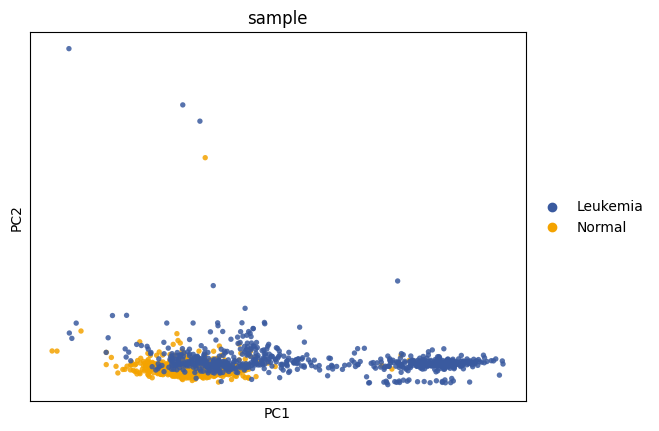

In [76]:
# Step 2: visualize PCA embedding colored by sample
sc.settings.figsize = (7, 6)
sc.pl.pca(
    adata_hvg,
    color="sample",
    palette=["#3A5A9F", "#F4A300"],   # Leukemia = red, Normal = teal
    size=60,          # was 20 — bigger dots
    alpha=0.85
     # add explicit figure size
)


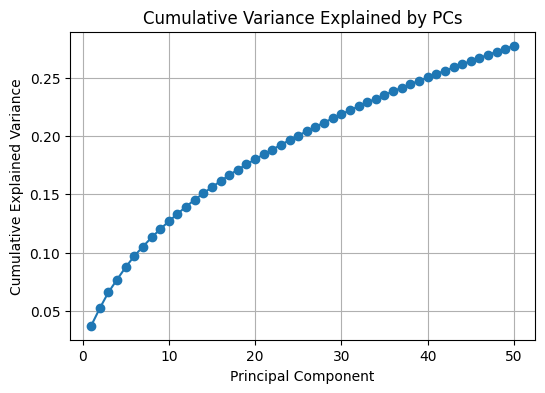

In [77]:
# Step 3: Compare variance captured by first few PCs vs remaining
explained_variance = adata_hvg.uns["pca"]["variance_ratio"]
cumulative_var = explained_variance.cumsum()
plt.figure(figsize=(6,4))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained by PCs")
plt.grid(True)
plt.show()

In [78]:
# Step 4: Inspect PCA output – explained variance
print("Explained variance ratio (first 10 PCs):")
print(adata_hvg.uns["pca"]["variance_ratio"][:10])

Explained variance ratio (first 10 PCs):
[0.03742216 0.01495947 0.01366495 0.01090519 0.01057574 0.00962931
 0.00800783 0.00783702 0.00705607 0.00679575]


In [79]:
# Step 5: Inspect gene loadings for PC1
# This shows which genes contribute most to PC1
pc1_genes = pd.Series(
    adata_hvg.varm["PCs"][:, 0],  # loadings of PC1
    index=adata_hvg.var_names
).sort_values(ascending=False)
print("Top 10 genes contributing to PC1:")
print(pc1_genes.head(10))

Top 10 genes contributing to PC1:
AHSP       0.127783
BLVRB      0.126305
APOC1      0.126195
KLF1       0.123237
FAM178B    0.122282
HBA1       0.122188
HBD        0.118345
ANK1       0.117484
S100A6     0.113794
PRDX2      0.112815
dtype: float64


In [80]:
# Step 6: Export PCA coordinates to CSV
pca_coords = pd.DataFrame(
    adata_hvg.obsm["X_pca"],
    index=adata_hvg.obs_names,
    columns=[f"PC{i+1}" for i in range(adata_hvg.obsm["X_pca"].shape[1])]
)
pca_coords.to_csv("PCA_coordinates.csv")

In [81]:
# Step 7: Check how many PCs are needed to cover 80% of variance
n_pcs_80 = sum(cumulative_var < 0.80)
print(f"Number of PCs to cover ~80% variance: {n_pcs_80}")

Number of PCs to cover ~80% variance: 50


In [82]:
# Step 8: Top genes per PC
top_genes_per_pc = adata_hvg.varm["PCs"][:, :5]  # first 5 PCs
top_genes_idx = [list(np.argsort(-abs(top_genes_per_pc[:,i]))[:5]) for i in range(5)]
for i, idx in enumerate(top_genes_idx):
    genes = adata_hvg.var_names[idx]
    print(f"Top genes for PC{i+1}: {list(genes)}")

Top genes for PC1: ['AHSP', 'BLVRB', 'APOC1', 'KLF1', 'FAM178B']
Top genes for PC2: ['ID3', 'MAGI1', 'PALM2-AKAP2', 'RGCC', 'PLPP3']
Top genes for PC3: ['GP1BB', 'ITGA2B', 'AL157895.1', 'PLEK', 'FCER1A']
Top genes for PC4: ['AC011139.1', 'IGLL1', 'SELENOP', 'IRF1', 'SOCS3']
Top genes for PC5: ['IGLL1', 'LGALS1', 'AC011139.1', 'DUSP1', 'MZB1']


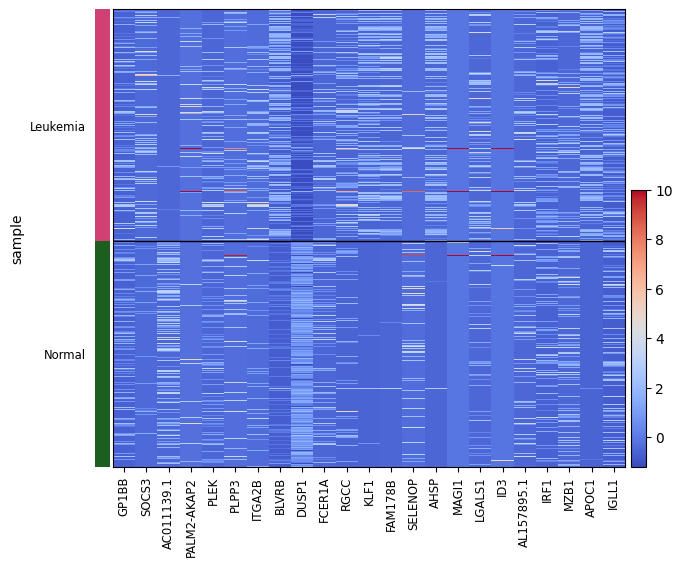

In [83]:
# Step 9: heatmap of top genes per PC (optional)
top_genes = set()
for idx in top_genes_idx:
    top_genes.update(adata_hvg.var_names[idx])
top_genes = list(top_genes)
# Assign colors to the sample categories
adata_hvg.uns["sample_colors"] = ["#CF4173", "#1B5E20"]
sc.pl.heatmap(
    adata_hvg,
    var_names=top_genes,
    groupby="sample",
    use_raw=False,
    show_gene_labels=True,
    cmap="coolwarm",

)

In [84]:
# =============================
# Step 1: Compute the neighborhood graph
# =============================

# Input: scaled HVG matrix (adata_hvg) with PCA already computed
# n_neighbors = 15 -> each cell is connected to its 15 closest neighbors
# n_pcs = 30 -> use first 30 PCs to calculate distances
sc.pp.neighbors(
    adata_hvg,
    n_neighbors=15,
    n_pcs=30
)

# Teaching explanation:
# Each cell is now connected to its 'closest' cells in PC space.
# Think of it as creating a "friendship network" among cells:
#   - Each cell has 15 closest friends (neighbors)
#   - Distance between friends = similarity in gene expression

In [85]:
# Step 2: Inspect the distance matrix
dist_matrix = adata_hvg.obsp["distances"].toarray()  # convert sparse matrix to dense
dist_matrix.shape  # should be (n_cells, n_cells)

(1368, 1368)

In [86]:
# Ignore diagonal (distance of a cell to itself)
np.fill_diagonal(dist_matrix, np.nan)

# Maximum distance
max_dist = np.nanmax(dist_matrix)
max_idx = np.unravel_index(np.nanargmax(dist_matrix), dist_matrix.shape)

print(f"Max distance: {max_dist}")
print(f"Between cells: {adata_hvg.obs_names[max_idx[0]]} and {adata_hvg.obs_names[max_idx[1]]}")

Max distance: 137.81861877441406
Between cells: CATCGGGAGGACGAAA-1 and TCGTACCAGTATCTCG-1


In [87]:
# Minimum distance (closest neighbors)
min_dist = np.nanmin(dist_matrix)
min_idx = np.unravel_index(np.nanargmin(dist_matrix), dist_matrix.shape)

print(f"Min distance: {min_dist}")
print(f"Between cells: {adata_hvg.obs_names[min_idx[0]]} and {adata_hvg.obs_names[min_idx[1]]}")

Min distance: 0.0
Between cells: AAACCTGAGGACCACA-1 and AAACGGGAGCAATATG-1


In [88]:
# Compute UMAP embedding from the neighborhood graph
sc.tl.umap(
    adata_hvg,
    min_dist=0.3,   # controls cluster compactness (How close cells are allowed to stand together)
    spread=1.0      # controls global separation
)

In [89]:
# UMAP coordinates (2D embedding)
umap_df = pd.DataFrame(
    adata_hvg.obsm["X_umap"],
    index=adata_hvg.obs_names,
    columns=["UMAP1", "UMAP2"]
)

umap_df.head()

,UMAP1,UMAP2
AAACCTGAGGACCACA-1,9.858554,1.942639
AAACGGGAGCAATATG-1,9.680982,8.796041
AAACGGGCATGTCTCC-1,6.844506,2.857984
AAACGGGTCGCGCCAA-1,6.481780,5.635617
AAAGATGGTAGAGTGC-1,6.871362,4.605500


In [90]:
umap_df.to_csv("UMAP_embeddings_cells.csv")

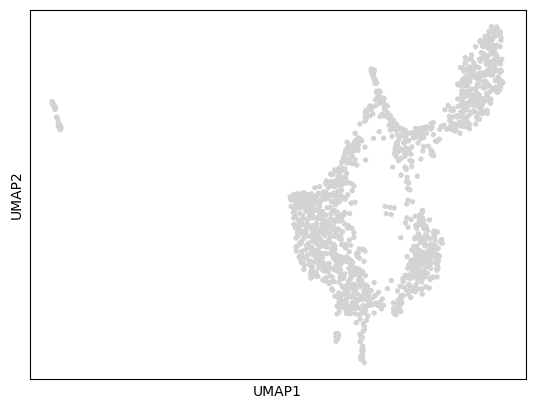

In [91]:
# Plain UMAP (structure only)
sc.pl.umap(
    adata_hvg,
    size=60
)

In [92]:
# Check the category order first
print(adata_hvg.obs["sample"].cat.categories)

Index(['Leukemia', 'Normal'], dtype='object')


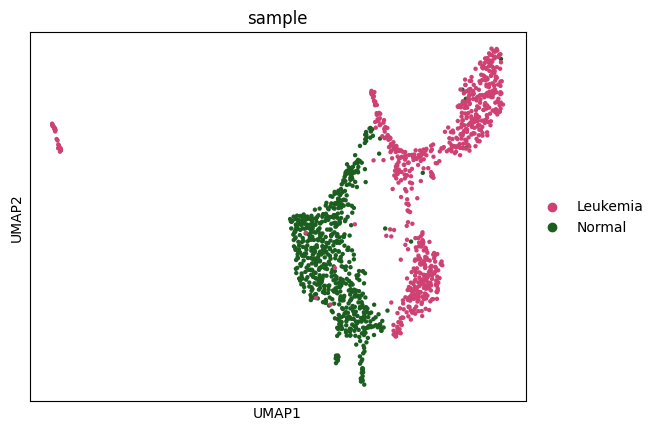

In [93]:
# Set colors in the same order as the categories
adata_hvg.uns["sample_colors"] = [
    "#CF4173",  # Leukemia — pink/red
    "#1B5E20"   # Normal — dark green
]
# UMAP colored by sample identity
sc.pl.umap(
    adata_hvg,
    color="sample",
    size=40
)

In [94]:
 pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 37.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 79.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [leidenalg]


In [95]:
import leidenalg

In [96]:
# Run Leiden clustering on the neighbor graph
sc.tl.leiden(
    adata_hvg,
    resolution=0.7,
    key_added="leiden_0.7"
)

/tmp/ipykernel_3973/3749247296.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


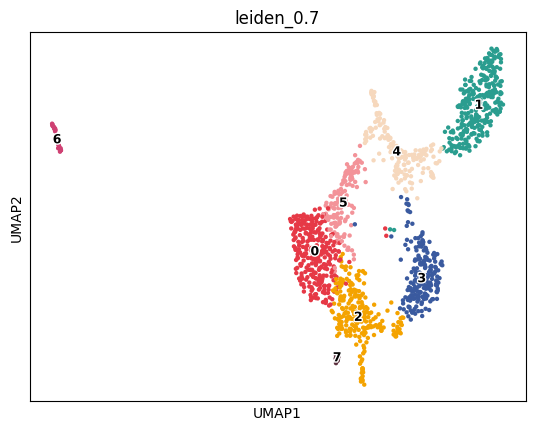

In [97]:
# Visualize UMAP colored by Leiden clusters
sc.pl.umap(
    adata_hvg,
    color="leiden_0.7",
    legend_loc="on data",
    legend_fontsize=9,
    legend_fontoutline=2,
    size=40,              # was 5 — bigger, more visible dots
    palette=["#E63946", "#2A9D8F", "#F4A300", "#3A5A9F","#F6D8BD","#F39399","#CF4173","#5D3140"],  # 8 clusters, high-contrast colors
)

In [98]:
# Run Leiden clustering at multiple resolutions
for res in [0.2, 0.3, 0.5, 0.7, 1.0]:
    sc.tl.leiden(
        adata_hvg,
        resolution=res,
        key_added=f"leiden_{res}"
    )

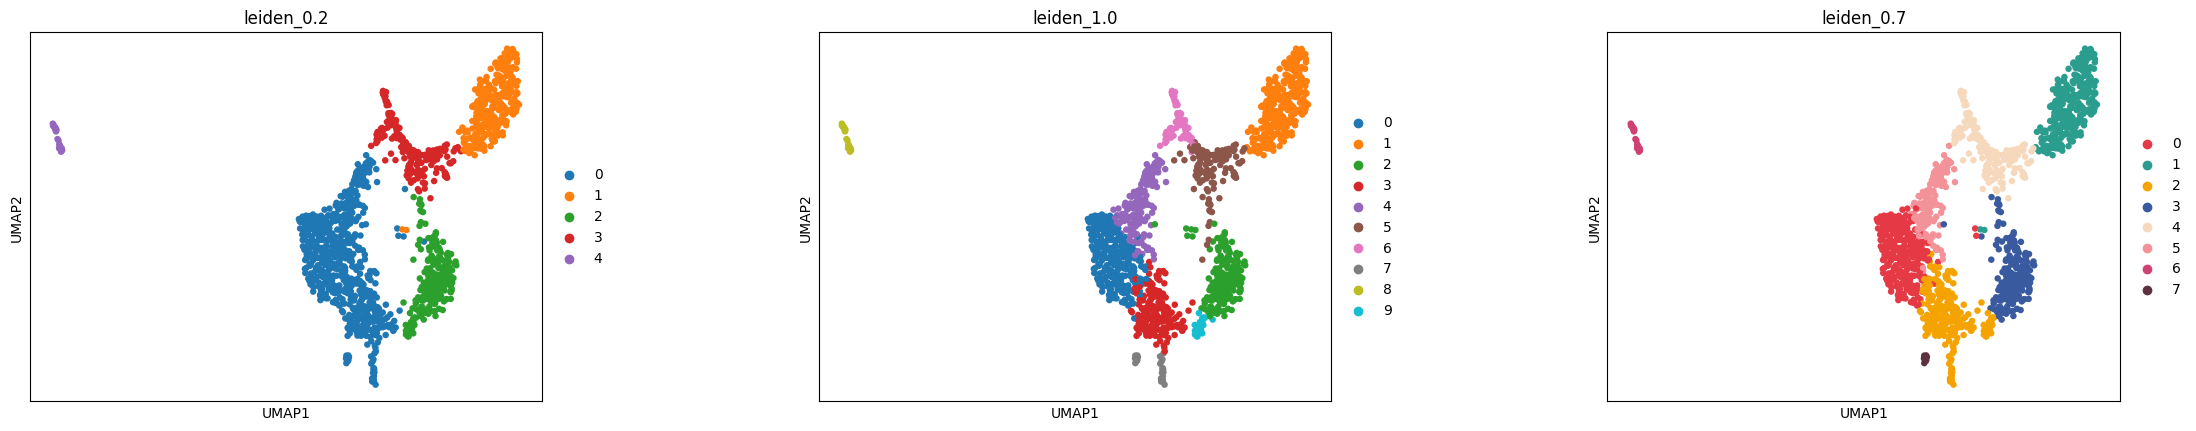

In [99]:
# Visualize UMAP colored by Leiden clusters at multiple resolutions
sc.pl.umap(
    adata_hvg,
    color=["leiden_0.2", "leiden_1.0", "leiden_0.7"],
    wspace=0.4
)

In [100]:
# Check the number of clusters at each resolution
adata_hvg.obs["leiden_0.7"].value_counts()

,count
leiden_0.7,
0,291
1,283
2,237
3,206
4,172
5,145
6,26
7,8


In [ ]:
# Export cluster assignments to CSV
adata_hvg.obs["leiden_0.7"].value_counts().to_csv(
    "Cluster_Cell_Counts.csv"
)

In [101]:
cluster_df = adata_hvg.obs[["sample", "leiden_0.7"]]
cluster_df.to_csv("Cell_Clusters_Leiden_0.7.csv")
cluster_df.head()

,sample,leiden_0.7
AAACCTGAGGACCACA-1,Normal,2
AAACGGGAGCAATATG-1,Normal,4
AAACGGGCATGTCTCC-1,Normal,0
AAACGGGTCGCGCCAA-1,Normal,0
AAAGATGGTAGAGTGC-1,Normal,0


In [102]:
adata_filtered.obs["leiden_0.7"] = adata_hvg.obs["leiden_0.7"]

In [103]:
# View the first few rows
adata_filtered.obs["leiden_0.7"].head()

,leiden_0.7
AAACCTGAGGACCACA-1,2
AAACGGGAGCAATATG-1,4
AAACGGGCATGTCTCC-1,0
AAACGGGTCGCGCCAA-1,0
AAAGATGGTAGAGTGC-1,0


In [104]:
adata_filtered.layers["lognorm"].shape

(1368, 36601)

In [105]:
# Marker genes for Leiden clusters at resolution 0.7
sc.tl.rank_genes_groups(
    adata_filtered,
    groupby="leiden_0.7",
    method="wilcoxon",
    layer="lognorm",     # uses log1p layer
    pts=True,
    use_raw=False        # ← important
)

In [106]:
# Export all marker genes for all clusters to CSV
marker_df = sc.get.rank_genes_groups_df(
    adata_filtered,
    group=None           # all clusters
)

marker_df.to_csv("Cluster_Marker_Genes.csv", index=False)
marker_df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,TPT1,20.314297,0.971552,9.611624e-92,3.517951e-87,0.993127,0.985144
1,0,AVP,19.682222,3.191680,3.062782e-86,5.605045e-82,0.934708,0.313835
2,0,RPL13,18.651703,0.656520,1.223207e-77,1.492354e-73,0.996564,0.986072
3,0,CD74,17.520254,1.819067,1.003757e-68,9.184625e-65,0.996564,0.911792
4,0,RPL9,17.263460,0.554760,8.863604e-67,6.488335e-63,0.989691,0.974002


In [107]:
# Define thresholds
LOGFC_CUTOFF = 1
PVALUE_CUTOFF = 0.05
PCT_GROUP_CUTOFF = 0.25
PCT_REF_CUTOFF = 0.25

# Extract the marker table
deg_df = sc.get.rank_genes_groups_df(
    adata_filtered,
    group=None
)

# Apply all gold-standard filters
filtered_deg_df = deg_df[
    (deg_df["pvals_adj"] <= PVALUE_CUTOFF) &
    ((deg_df["logfoldchanges"] >= LOGFC_CUTOFF) |
     (deg_df["logfoldchanges"] <= -LOGFC_CUTOFF)) &
    (deg_df["pct_nz_group"] >= PCT_GROUP_CUTOFF) &
    (deg_df["pct_nz_reference"] <= PCT_REF_CUTOFF)
].copy()

# Save refined markers
filtered_deg_df.to_csv("Refined_Marker_Genes_GoldStandard.csv", index=False)

# View top markers
for cluster in filtered_deg_df["group"].unique():
    print(f"\nCluster {cluster} top markers:")
    display(filtered_deg_df[filtered_deg_df["group"]==cluster].head(5))


Cluster 0 top markers:


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
61,0,AC011139.1,11.629050,2.607590,2.933422e-31,1.154475e-28,0.573883,0.130919
71,0,PCDH9,11.252096,2.077477,2.261519e-29,7.325120e-27,0.618557,0.212628
102,0,TLE4,9.356707,1.955511,8.226101e-21,1.387482e-18,0.522337,0.197772
111,0,MIR99AHG,8.910014,1.808640,5.102608e-19,7.622880e-17,0.525773,0.224698
114,0,EVI2B,8.780656,1.779000,1.625245e-18,2.367570e-16,0.512027,0.211699



Cluster 1 top markers:


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
36602,1,APOC1,25.560003,7.217290,4.250530e-144,7.778683e-140,0.992933,0.058065
36605,1,AHSP,25.379047,8.287460,4.296459e-142,3.145094e-138,0.985866,0.054378
36607,1,FAM178B,25.231546,7.909083,1.805774e-140,9.441876e-137,0.975265,0.021198
36610,1,KLF1,24.759138,5.470652,2.471744e-135,9.046829e-132,0.975265,0.074654
36613,1,ANK1,24.263920,6.463026,4.714731e-130,1.327414e-126,0.950530,0.026728



Cluster 2 top markers:


...

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
183009,5,AC011139.1,12.362367,3.303061,4.176776e-35,3.057484e-31,0.758621,0.161897
183014,5,FCER1A,10.796075,2.951431,3.592353e-27,1.314837e-23,0.703448,0.203598
183028,5,AL157895.1,9.685775,2.815349,3.465703e-22,4.878776e-19,0.627586,0.154538
183057,5,ZNF385D-AS2,7.881149,2.614120,3.243845e-15,1.746000e-12,0.510345,0.127555
183133,5,DYTN,5.689229,1.580452,1.276137e-08,2.312272e-06,0.468966,0.191333



Cluster 6 top markers:


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
219611,6,ALAS2,5.674280,5.682816,1.392732e-08,7.977370e-07,0.692308,0.139344
219612,6,IFI27,5.389588,5.790251,7.061917e-08,3.545586e-06,0.653846,0.089419
219618,6,FAM210B,3.753616,3.355353,1.743021e-04,3.733881e-03,0.538462,0.233979
219623,6,CA1,3.285729,3.257725,1.017187e-03,1.742980e-02,0.500000,0.181073
219624,6,BPGM,3.128097,4.571980,1.759424e-03,2.772092e-02,0.423077,0.113264



Cluster 7 top markers:


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
256207,7,MS4A1,4.882850,33.069180,0.000001,0.006358,1.000,0.000000
256210,7,PLEKHG1,4.872976,7.512851,0.000001,0.006358,1.000,0.047059
256224,7,CD79A,4.254991,8.562753,0.000021,0.029430,0.875,0.028676
256225,7,OSBPL10,4.224024,6.474733,0.000024,0.031265,0.875,0.051471
256227,7,BANK1,4.209214,6.398678,0.000026,0.031265,0.875,0.103676


In [108]:
# save refined markers
filtered_deg_df.to_csv("Refined_Marker_Genes.csv", index=False)

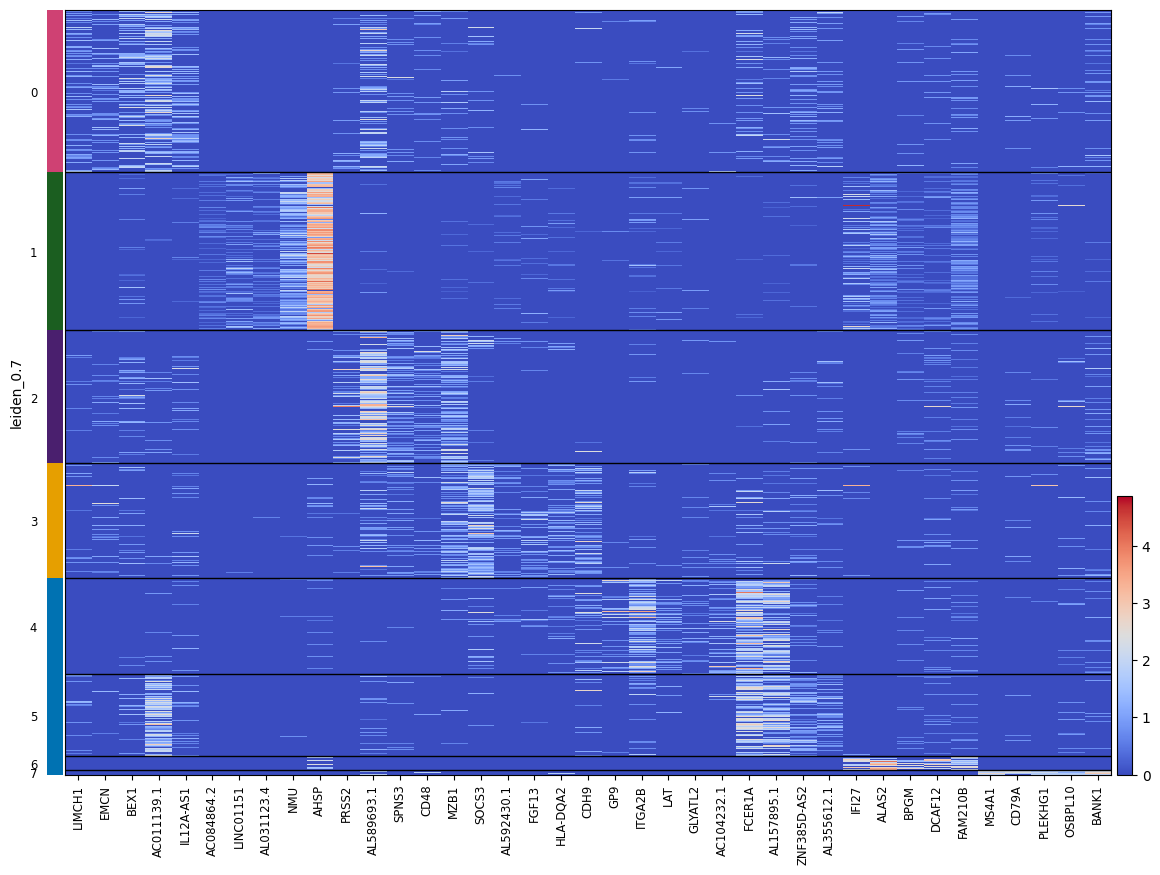

In [109]:
# Select top 5 markers per cluster
top_n = 5
top_markers = (
    filtered_deg_df.groupby("group")
    .apply(lambda x: x.nlargest(top_n, "logfoldchanges"))
    .reset_index(drop=True)
)

# Extract gene names
genes_to_plot = top_markers["names"].unique().tolist()

# Custom colors for Leiden clusters
adata_filtered.uns["leiden_0.7_colors"] = [
    "#CF4173",  # Cluster 0
    "#1B5E20",  # Cluster 1
    "#4A1F6E",  # Cluster 2
    "#E69F00",  # Cluster 3
    "#0072B2"   # Cluster 4
]
# Heatmap using Scanpy
sc.pl.heatmap(
    adata_filtered,
    var_names=genes_to_plot,
    groupby="leiden_0.7",
    use_raw=False,       # uses lognorm layer
    layer="lognorm",
    swap_axes=False,     # clusters on y-axis, genes on x-axis
    cmap="coolwarm",
    show_gene_labels=True,
    figsize=(14,10)
)

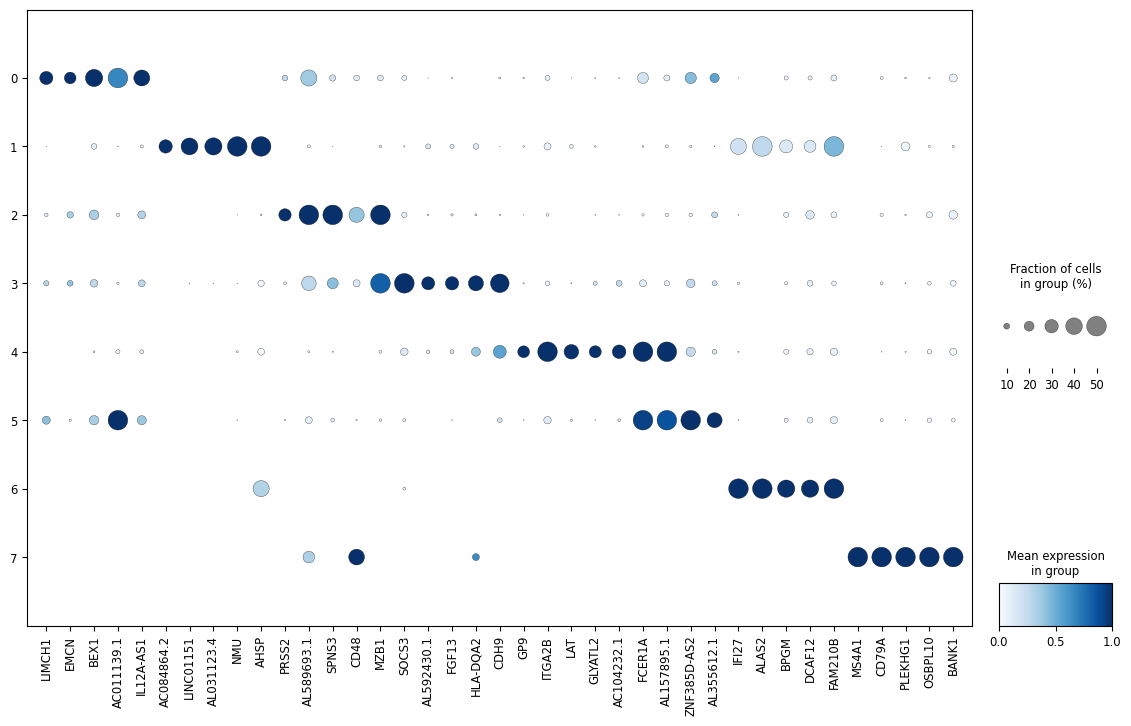

In [110]:
# Dotplot using Scanpy
sc.pl.dotplot(
    adata_filtered,
    var_names=genes_to_plot,
    groupby="leiden_0.7",
    use_raw=False,
    layer="lognorm",
    standard_scale="var",  # scales each gene to [0,1] for comparability
    dot_max=0.5,
    figsize=(14,8),
    cmap="Blues"
)

In [111]:
pip install celltypist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 70.1 MB/s  0:00:00


In [112]:
# CellTypist for automated cell type annotation
import celltypist
from celltypist import models

In [113]:
# Show all available models (locally downloaded or from remote index)
model_list_df = models.models_description(on_the_fly=True)

print(model_list_df)

                                      model  \
0           Mouse_Isocortex_Hippocampus.pkl   
1                Cells_Intestinal_Tract.pkl   
2                       Adult_Human_MTG.pkl   
3   Adult_CynomolgusMacaque_Hippocampus.pkl   
4                        Immune_All_Low.pkl   
..                                      ...   
56                 Autopsy_COVID19_Lung.pkl   
57                       Human_IPF_Lung.pkl   
58                    Cells_Lung_Airway.pkl   
59                 Healthy_COVID19_PBMC.pkl   
60              Human_Endometrium_Atlas.pkl   

                                          description  
0   cell types from the adult mouse isocortex (neo...  
1   intestinal cells from fetal, pediatric (health...  
2   cell types and subtypes (10x-based) from the a...  
3   cell types from the hippocampus of adult cynom...  
4   immune sub-populations combined from 20 tissue...  
..                                                ...  
56  cell types from the lungs of 16 SARS-Co

In [114]:
adata_filtered

AnnData object with n_obs × n_vars = 1368 × 36601
    obs: 'sample', 'sample_id', 'n_genes', 'n_counts', 'counts_per_gene', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_raw', 'total_counts_normalized', 'leiden_0.7'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'rank_genes_groups', 'leiden_0.7_colors'
    layers: 'lognorm'

In [163]:
# Make a copy of your filtered AnnData
adata_ct = adata_filtered.copy()

In [164]:
# Use the log-normalized data for CellTypist
adata_ct.X = adata_filtered.layers["lognorm"]

In [165]:
adata_ct.shape

(1368, 36601)

In [166]:
from celltypist import models, annotate

# Load the model
model = models.Model.load("Adult_cHSPCs_Illumina.pkl")

In [167]:
# Model description
models.models_description()

,model,description
0,Immune_All_Low.pkl,immune sub-populations combined from 20 tissue...
1,Immune_All_High.pkl,immune populations combined from 20 tissues of...
2,Adult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types from C...
3,Adult_CynomolgusMacaque_Hippocampus.pkl,cell types from the hippocampus of adult cynom...
4,Adult_Human_MTG.pkl,cell types and subtypes (10x-based) from the a...
...,...,...
56,Nuclei_Lung_Airway.pkl,cell populations from snRNA-seq of five locati...
57,PaediatricAdult_COVID19_Airway.pkl,cell types in the airway of paediatric and adu...
58,PaediatricAdult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types of pae...
59,Pan_Fetal_Human.pkl,stromal and immune populations from the human ...


In [168]:
# Run annotation with majority voting
predictions = annotate(
    adata_ct,
    model=model,
    majority_voting=True
)

In [169]:
predictions

CellTypist prediction result for 1368 query cells
    predicted_labels: data frame with 3 columns ('predicted_labels', 'over_clustering', 'majority_voting')
    decision_matrix: data frame with 1368 query cells and 20 cell types
    probability_matrix: data frame with 1368 query cells and 20 cell types
    adata: AnnData object referred

In [170]:
predictions.adata.obs.shape

(1368, 14)

In [171]:
# Check the predicted labels
predictions.predicted_labels.majority_voting.value_counts()

,count
majority_voting,
HSC_MPP,794
ERYP,340
MEBEMP-L,101
MKP,79
GMP-L,33
BEMP,15
B,10


In [172]:
# Remove duplicated indices (if any) from predicted labels
predicted_labels_clean = predictions.predicted_labels[predictions.predicted_labels.index.duplicated(keep='first') == False]

print(predicted_labels_clean.shape)
print(predicted_labels_clean.index.duplicated().sum())

(1366, 3)
0


In [173]:
# Map the predicted labels back to the original AnnData object
adata_ct.obs['celltypist_majority'] = adata_ct.obs_names.map(
    predicted_labels_clean['majority_voting']
)

In [175]:
# Check the distribution of predicted labels in the original AnnData object
adata_ct.obs['celltypist_majority'].value_counts(dropna=False)

,count
celltypist_majority,
HSC_MPP,794
ERYP,336
MEBEMP-L,101
MKP,79
GMP-L,33
BEMP,15
B,10


In [176]:
adata_ct

AnnData object with n_obs × n_vars = 1368 × 36601
    obs: 'sample', 'sample_id', 'n_genes', 'n_counts', 'counts_per_gene', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_raw', 'total_counts_normalized', 'leiden_0.7', 'celltypist_majority'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'rank_genes_groups', 'leiden_0.7_colors', 'neighbors', 'over_clustering'
    obsm: 'X_pca'
    layers: 'lognorm'
    obsp: 'connectivities', 'distances'

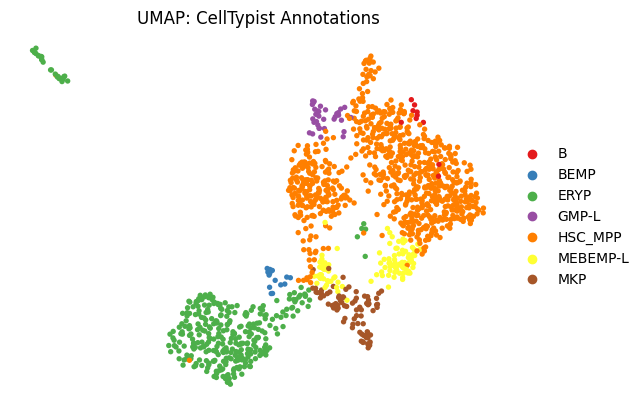

In [177]:
# Compute UMAP if not already done
if 'X_umap' not in adata_ct.obsm:
    sc.tl.umap(adata_ct)
custom_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',
                  '#ffff33', '#a65628', '#1B5E20']

# Plot UMAP with legend outside
sc.pl.umap(
    adata_ct,
    color='celltypist_majority',
    legend_loc='right margin',  # place legend outside
    title='UMAP: CellTypist Annotations',
    frameon=False,              # removes frame for cleaner view
    size=60,                     # adjust dot size
    palette= custom_colors
)

In [178]:
# Cross-tabulation of clusters vs CellTypist labels
pd.crosstab(
    adata_ct.obs['leiden_0.7'],
    adata_ct.obs['celltypist_majority']
)

celltypist_majority,B,BEMP,ERYP,GMP-L,HSC_MPP,MEBEMP-L,MKP
leiden_0.7,,,,,,,
0,2,0,1,0,288,0,0
1,0,0,282,0,1,0,0
2,1,0,0,32,204,0,0
3,0,0,1,1,203,1,0
4,0,15,27,0,17,35,78
5,0,0,0,0,79,65,1
6,0,0,25,0,1,0,0
7,7,0,0,0,1,0,0


In [179]:
# Select relevant columns
student_csv = adata_ct.obs[['sample', 'sample_id', 'leiden_0.7', 'celltypist_majority']]

# Save
student_csv.to_csv("Annotated_Cells_UMAP.csv")

In [181]:
# Output directory for DEGs
output_dir = "/content/Project_scRNAseq/Project_scRNAseq/DEG_outputs_model1"
os.makedirs(output_dir, exist_ok=True)

In [182]:
# Define reference sample
reference_sample = "Normal"
print(reference_sample)

Normal


In [183]:
# Volcano plot thresholds
padj_thresh = 0.05
logfc_thresh = 1

In [184]:
# List all unique cell types
cell_types = adata_ct.obs['celltypist_majority'].unique()
print("Cell types found:", cell_types)

Cell types found: ['HSC_MPP', 'MKP', 'MEBEMP-L', 'B', 'GMP-L', 'ERYP', 'BEMP']
Categories (7, object): ['B', 'BEMP', 'ERYP', 'GMP-L', 'HSC_MPP', 'MEBEMP-L', 'MKP']


In [185]:
# Loop through each cell type
for cell in cell_types:
    print(f"\nProcessing cell type: {cell}")

    # Subset AnnData for the specific cell type
    adata_cell = adata_ct[adata_ct.obs['celltypist_majority'] == cell].copy()

    # Check number of cells per sample
    sample_counts = adata_cell.obs['sample'].value_counts()
    print(sample_counts)

     # Skip if fewer than 2 groups present, or if either group is too small
    if sample_counts.shape[0] < 2:
        print(f"Skipping {cell}: only one sample group present, cannot run DE")
        continue

    if (sample_counts < 3).any():  # optional: minimum cell threshold per group
        print(f"Skipping {cell}: one or more groups has too few cells (<3)")
        continue

    # Differential expression analysis
    sc.tl.rank_genes_groups(
        adata_cell,
        groupby="sample",
        reference=reference_sample,
        method="wilcoxon",
        layer="lognorm",
        pts=True,
        use_raw=False
    )

    # Extract DEGs
    degs = sc.get.rank_genes_groups_df(
        adata_cell,
        group="Leukemia"
    )

    # Apply thresholds
    degs["Significant"] = "Not Sig"

    degs.loc[
        (degs["pvals_adj"] < padj_thresh) &
        (
            (degs["logfoldchanges"] >= logfc_thresh) |
            (degs["logfoldchanges"] <= -logfc_thresh)
        ),
        "Significant"
    ] = "Significant"

    degs_sig = degs[degs["Significant"] == "Significant"]

    # Create folder for this cell type
    safe_cell_name = cell.replace(" ", "_").replace("/", "-")
    cell_folder = os.path.join(output_dir, safe_cell_name)
    os.makedirs(cell_folder, exist_ok=True)

    # Save raw DEGs and significant DEGs separately
    degs.to_csv(os.path.join(cell_folder, f"{safe_cell_name}_all_DEGs.csv"), index=False)
    degs_sig.to_csv(os.path.join(cell_folder, f"{safe_cell_name}_significant_DEGs.csv"), index=False)
    ...
    plot_file = os.path.join(cell_folder, f"{safe_cell_name}_volcano.png")

    print(f"DEGs saved for {cell}: total={len(degs)}, significant={len(degs_sig)}")

    # -------------------------
    # Volcano plot
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=degs,
        x='logfoldchanges',
        y=-np.log10(degs['pvals_adj'] + 1e-300),  # avoid -inf
        hue='Significant',
        palette={'Not Sig':'gray', 'Significant':'red'},
        alpha=0.7
    )

    # Add threshold lines
    plt.axvline(x=logfc_thresh, color='blue', linestyle='--', lw=1)
    plt.axvline(x=-logfc_thresh, color='blue', linestyle='--', lw=1)
    plt.axhline(y=-np.log10(padj_thresh), color='green', linestyle='--', lw=1)

    plt.title(f"Volcano Plot: {cell}")
    plt.xlabel("Log2 Fold Change")
    plt.ylabel("-Log10 Adjusted P-value")
    plt.legend(title='Significance')

    # Save volcano plot
    plot_file = os.path.join(cell_folder, f"{safe_cell_name}_volcano.png")
    plt.tight_layout()
    plt.savefig(plot_file, dpi=300)
    plt.close()

    print(f"Volcano plot saved for {safe_cell_name}")


Processing cell type: HSC_MPP
sample
Normal      566
Leukemia    228
Name: count, dtype: int64
DEGs saved for HSC_MPP: total=36601, significant=244
Volcano plot saved for HSC_MPP

Processing cell type: MKP
sample
Leukemia    64
Normal      15
Name: count, dtype: int64
DEGs saved for MKP: total=36601, significant=9
Volcano plot saved for MKP

Processing cell type: MEBEMP-L
sample
Normal      66
Leukemia    35
Name: count, dtype: int64
DEGs saved for MEBEMP-L: total=36601, significant=67
Volcano plot saved for MEBEMP-L

Processing cell type: B
sample
Normal    10
Name: count, dtype: int64
Skipping B: only one sample group present, cannot run DE

Processing cell type: GMP-L
sample
Leukemia    22
Normal      11
Name: count, dtype: int64
DEGs saved for GMP-L: total=36601, significant=0
Volcano plot saved for GMP-L

Processing cell type: ERYP
sample
Leukemia    329
Normal        7
Name: count, dtype: int64
DEGs saved for ERYP: total=36601, significant=0
Volcano plot saved for ERYP

Processi

In [ ]:
import shutil

shutil.make_archive("DEG_outputs", 'zip', "/content/Project_scRNAseq/Project_scRNAseq/DEG_outputs")
shutil.make_archive("DEG_outputs_model2", 'zip', "/content/Project_scRNAseq/Project_scRNAseq/DEG_outputs_model2")
shutil.make_archive("DEG_outputs_model3", 'zip', "/content/Project_scRNAseq/Project_scRNAseq/DEG_outputs_model3")

'/content/Project_scRNAseq/Project_scRNAseq/DEG_outputs_model3.zip'